We'll make a DecisionTree Model based on these classes: race, income group, age group, American identity, and whether or not they voted in order to predict preferred candidate.

A Decision Tree is apt, because we'll divide our voters up by these attributes, and we'll see what combination of features will lead to what prediction.

In [3]:
# Import libraries
import pandas as pd

In [4]:
# Loading in the dataset

anes2024_csv = "../../dataset/data_2024/anes_timeseries_2024_csv_20250808.csv"
df2024 = pd.read_csv(anes2024_csv)

df2024_select = df2024[["V241501x", "V241567x", "V241566x", "V241039", "V240108a",
                        "V240002c", "V242067", # Race, Income, Presidential Choice
                        "V241458x", # Age
                        "V242066", # Voted?
                        "V242536" # American Identity
                        ]]
df2024_select

C:\Users\james\AppData\Local\Temp\ipykernel_52472\3428814666.py:4: DtypeWarning: Columns (0: V240101a, 1: V240101c, 2: V240101d, 3: V240103a, 4: V240103c, 5: V240103d, 6: V240104a, 7: V240104c, 8: V240104d, 9: V240105a, 10: V240105c, 11: V240105d, 12: V240106a, 13: V240106c, 14: V240106d, 15: V240108a, 16: V240108c, 17: V240108d, 18: V243002, 19: V243003, 20: V243004, 21: V243005, 22: V243006, 23: V243009, 24: V243050, 25: V243051, 26: V243052, 27: V243053, 28: V243056, 29: V243057, 30: V243058) have mixed types. Specify dtype option on import or set low_memory=False.
  df2024 = pd.read_csv(anes2024_csv)


,V241501x,V241567x,V241566x,V241039,V240108a,V240002c,V242067,V241458x,V242066,V242536
0,3,5,27,-1,0.809064,2,2,50,1,1
1,4,5,26,-1,2.575472,2,-1,41,-1,3
2,1,5,24,-1,0.798864,2,1,44,1,5
3,4,3,12,-1,0.244757,2,-1,45,-1,2
4,1,3,15,-1,0.239209,2,2,80,1,4
...,...,...,...,...,...,...,...,...,...,...
5516,-8,2,5,-1,0.19183,1,-6,-2,-6,-6
5517,1,3,16,-1,2.869063,2,1,69,1,3
5518,2,3,12,-9,2.092296,1,-6,-2,-6,-6
5519,2,4,19,-1,2.826738,2,1,28,1,3


In [5]:
# Dictionaries for conversion

race_dict = { # V241501x
    -9: "Refused",
    -8: "Don’t Know",
    -4: "Error",
    1: "White", #"White, non-Hispanic",
    2: "Black", #"Black, non-Hispanic",
    3: "Hispanic",
    4: "Asian/Pacific-Islander", #"Asian or Native Hawaiian/other Pacific Islander, non-Hispanic",
    5: "Native American/Other", #"Native American/Alaska Native or other race, non-Hispanic",
    6: "Multiple Races", #"Multiple races, non-Hispanic",
}

household_income_6_cat_dict = { # V241567x
    -9: "Refused",
    -5: "Break off, sufficient partial",
    -4: "Error",
    1: "<$10k", #"Under $9,999",
    2: "$10k-30k", #"$10,000 to $29,999",
    3: "$30k-60k", #"$30,000 to $59,999",
    4: "$60k-100k", #"$60,000 to $99,999",
    5: "$100k-250k", #"$100,000 to $249,999",
    6: "$250k+", #"$250,000 or more",
}

# Okay, forget the 28-category one.

president_dict = { # V242067
    -9: "Refused",
    -1: "Inapplicable",
    1: "Harris", #"Kamala Harris",
    2: "Trump", #"Donald Trump",
    3: "RFK Jr.", #"Robert F. Kennedy, Jr.",
    4: "West", #"Cornel West",
    5: "Stein", #"Jill Stein",
    6: "Other", #"Another candidate {SPECIFY}"
}

complete_survey_dict = {
    1: 0,
    2: 1
}

#V242066 - Did R vote for President
voted_dict = {
    -7: "Insufficient Partial",
    -6: "No Post Interview",
    -1: "Inapplicable",
    1: "Yes",
    2: "No"
}

def age_group(age):
    if age < 18:
        return "Under 18"
    elif age >= 18 and age < 45:
        return "18-44"
    elif age >= 45 and age < 65:
        return "45-64"
    elif age >= 65:
        return "65 and over"
    else:
        return "Missing"
    
nationalism_dict = { # V242536
    -9: "Refused",
    -7: "Insufficient partial, interview deleted",
    -6: "No post interview",
    -5: "Sufficient partial, breakoff",
    -1: "Inapplicable",
    1: "Extremely important",
    2: "Very important",
    3: "Moderately important",
    4: "A little important",
    5: "Not at all important"
}

In [6]:
# Making the dataset more readable
df2024_select["Race"] = df2024_select["V241501x"].map(race_dict)
df2024_select["Household Income"] = df2024_select["V241567x"].map(household_income_6_cat_dict)
df2024_select["President Vote"] = df2024_select["V242067"].map(president_dict)
df2024_select["Completed Survey"] = df2024_select["V240002c"].map(complete_survey_dict)
df2024_select["Voted"] = df2024_select["V242066"].map(voted_dict)
df2024_select["Age Group"] = df2024_select["V241458x"].apply(age_group)
df2024_select["American Identity"] = df2024_select["V242536"].map(nationalism_dict)

# Clean up 'Weights': replace empty strings with 0.
df2024_select["Weights"] = df2024_select["V240108a"]
df2024_select["Weights"] = df2024_select["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df2024_select["Weights"] = df2024_select["Weights"].astype(float)

df2024_clean = df2024_select[["Race", "Household Income", "Age Group", "American Identity",
                              "President Vote", "Completed Survey", "Weights"]]

df2024_clean

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
1,Asian/Pacific-Islander,$100k-250k,18-44,Moderately important,Inapplicable,1,2.575472
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
3,Asian/Pacific-Islander,$30k-60k,45-64,Very important,Inapplicable,1,0.244757
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
...,...,...,...,...,...,...,...
5516,Don’t Know,$10k-30k,Under 18,No post interview,NaN,0,0.191830
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5518,Black,$30k-60k,Under 18,No post interview,NaN,0,2.092296
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [7]:
# Dealing with missing values
df2024_clean.dropna()
df2024_clean


# Order variables
incomes = ["<$10k", "$10k-30k", "$30k-60k", "$60k-100k", "$100k-250k", "$250k+",
           "Refused", "Break off, sufficient partial", "Error"]
df2024_clean["Household Income"] = pd.Categorical(values = df2024_clean["Household Income"],
                                                  categories = incomes, ordered = True)
nationalism = ["Not at all important", "A little important", "Moderately important",
               "Very important", "Extremely important", "Refused", "Inapplicable",
               "No post interview", "Insufficient partial, interview deleted",
               "Sufficient partial, breakoff"]
df2024_clean["American Identity"] = pd.Categorical(values = df2024_clean["American Identity"],
                                                  categories = nationalism, ordered = True)

# Only keep people who completed the survey.
df2024_relevant = df2024_clean[df2024_clean["Completed Survey"] == 1]

df2024_relevant

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
1,Asian/Pacific-Islander,$100k-250k,18-44,Moderately important,Inapplicable,1,2.575472
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
3,Asian/Pacific-Islander,$30k-60k,45-64,Very important,Inapplicable,1,0.244757
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
...,...,...,...,...,...,...,...
5514,White,$100k-250k,18-44,Very important,Inapplicable,1,0.797417
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [8]:
# Simplifying Data to only people that answered with an actual category.
df2024_simplified = df2024_relevant[df2024_relevant["Race"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["Race"] != "Inapplicable"]

# Turn third-party candidates into one category.
def collapse_third_party(vote):
    if vote in ["West", "Stein", "Other"]:
        return "Other"
    else:
        return vote

df2024_simplified["President Vote"] = df2024_simplified["President Vote"].apply(collapse_third_party)

# Filter to people who answered about who the voted for.
df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Inapplicable"]

# Filter to people who answered about their income
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Error"]
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Break off, sufficient partial"]

# Filter to people who answred about their age
df2024_simplified = df2024_simplified[df2024_simplified["Age Group"] != "Missing"]

# Filter to people who answered about American Identity
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Inapplicable"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "No post interview"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Insufficient partial, interview deleted"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Sufficient partial, breakoff"]


df2024_simplified = df2024_simplified[df2024_simplified["President Vote"].isna() != True]
df2024_simplified

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
6,White,$30k-60k,18-44,Moderately important,Trump,1,0.290135
10,White,$100k-250k,45-64,Moderately important,Harris,1,0.940042
...,...,...,...,...,...,...,...
5507,White,$60k-100k,45-64,Moderately important,Other,1,3.652063
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


We have our dataset. We'll train a DecisionTreeClassifier from Scikit-Learn to predict a person's preferred candidate based on their race, household income, age group, and perceived importance of American Identity.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

"Other" category may not be as important, because it is so sparse. So how about we trim the dataset down to just predicting Trump/Harris, and we'll use a binary encoding.

In [10]:
# Make the output binary.
df2024_binary = df2024_simplified[df2024_simplified["President Vote"] != "Other"]

df2024_binary["President Vote Binary"] = df2024_binary["President Vote"].apply(lambda vote:  1 if vote == "Harris" else 0)
df2024_binary

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights,President Vote Binary
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064,0
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864,1
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209,0
6,White,$30k-60k,18-44,Moderately important,Trump,1,0.290135,0
10,White,$100k-250k,45-64,Moderately important,Harris,1,0.940042,1
...,...,...,...,...,...,...,...,...
5506,White,$60k-100k,45-64,Extremely important,Harris,1,0.256140,1
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755,1
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063,1
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738,1


In [11]:
# Catboost Decision Tree with binary output
seed = 42 # For determinism

X = df2024_binary[["Race", "Household Income", "Age Group", "American Identity"]]
y = df2024_binary["President Vote"]
w = df2024_binary["Weights"]

# Split data into training sets and test sets.
test_size = 0.2
Xtrain, Xtest, ytrain, ytest, wtrain, wtest = train_test_split(X, y, w, test_size=test_size,
                                                               random_state=seed, stratify=y)

In [12]:
# Training the Decision Tree
categories = X.columns.tolist()
# Use CatBoost, because it works on categorical data.
cat_dtree_bin = CatBoostClassifier(random_state=seed,
                               cat_features=categories,
                               verbose = 0)

cat_dtree_bin.fit(Xtrain, ytrain, sample_weight=wtrain)

CatBoostClassifier(cat_features=['Race', 'Household Income', 'Age Group', 'American Identity'], random_state=42, verbose=0)

0.7132883897772595


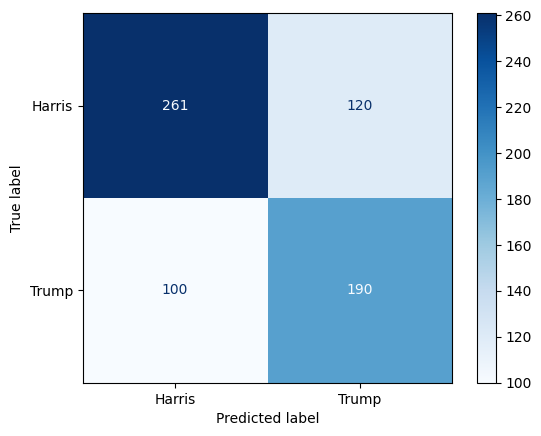

In [13]:
# Evaluation on test data.
y_pred = cat_dtree_bin.predict(Xtest)

accuracy = accuracy_score(ytest, y_pred, sample_weight=wtest)
print(accuracy)

con_mat = confusion_matrix(ytest, y_pred)
labels = cat_dtree_bin.classes_
plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
plot.plot(cmap = plt.cm.Blues)

0.728780983753099


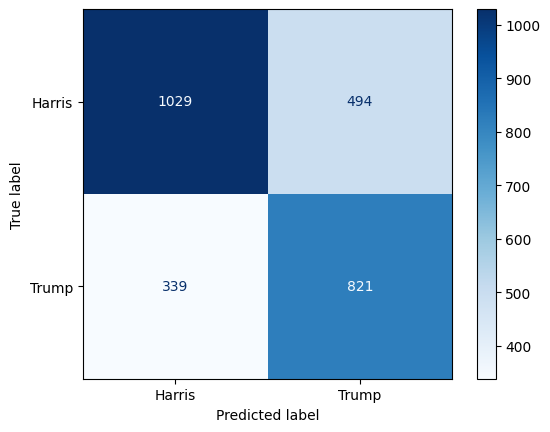

In [14]:
# Evaluation on train data.
y_pred_train = cat_dtree_bin.predict(Xtrain)

accuracy = accuracy_score(ytrain, y_pred_train, sample_weight=wtrain)
print(accuracy)

con_mat = confusion_matrix(ytrain, y_pred_train)
labels = cat_dtree_bin.classes_
plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
plot.plot(cmap = plt.cm.Blues)

In [15]:
# We will go and display the confusion matrices per each result.
dfresults = Xtest.copy()
dfresults["Prediction"] = y_pred
dfresults["Actual"] = ytest
dfresults["Weight"] = wtest
dfresults

,Race,Household Income,Age Group,American Identity,Prediction,Actual,Weight
666,Hispanic,$100k-250k,18-44,Extremely important,Harris,Harris,1.479550
2738,White,$60k-100k,45-64,Very important,Trump,Trump,0.175571
2421,White,$100k-250k,45-64,Extremely important,Trump,Trump,0.640016
1111,White,$60k-100k,45-64,Very important,Trump,Harris,0.829128
4038,Multiple Races,$100k-250k,18-44,Very important,Harris,Trump,1.874986
...,...,...,...,...,...,...,...
4298,Hispanic,$30k-60k,18-44,Moderately important,Harris,Trump,0.722789
2346,White,$250k+,65 and over,Moderately important,Harris,Harris,3.250217
3685,White,$60k-100k,45-64,Moderately important,Harris,Harris,0.388935
1136,Asian/Pacific-Islander,$100k-250k,18-44,Extremely important,Trump,Trump,0.660018


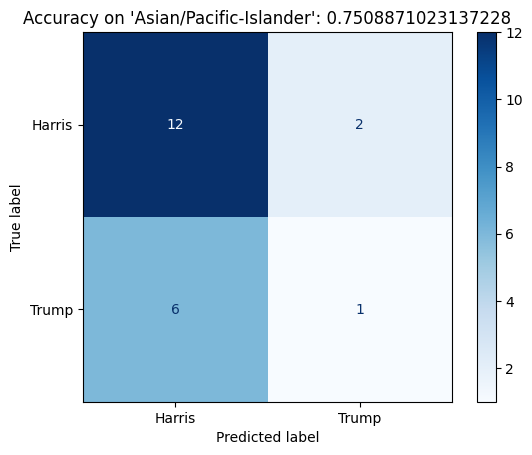

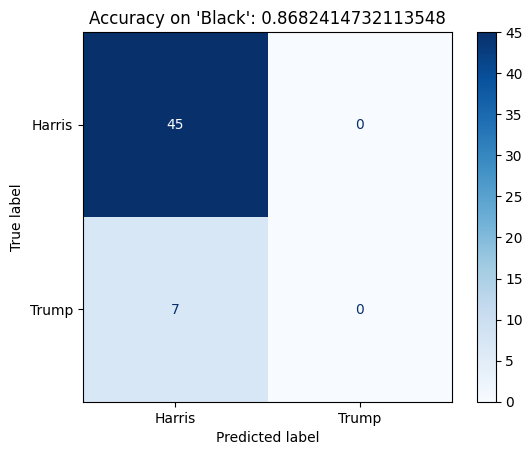

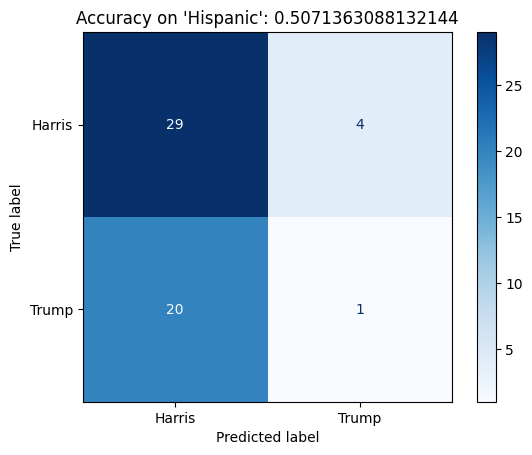

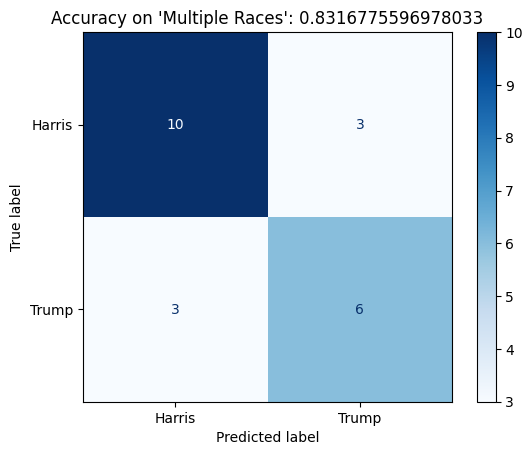

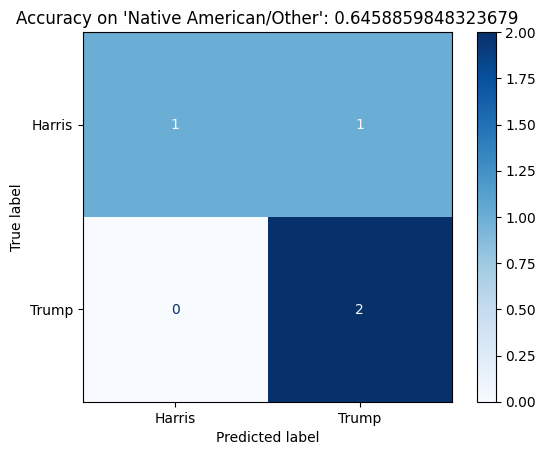

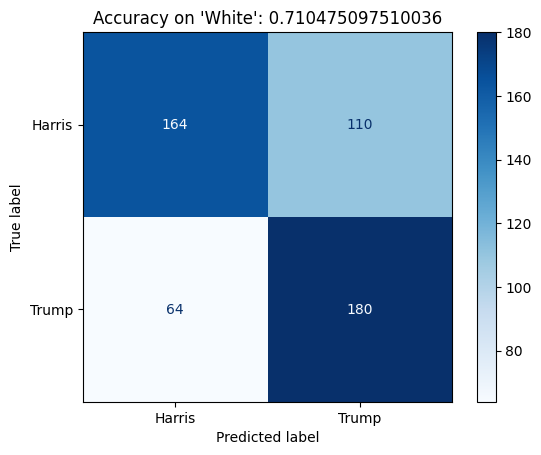

In [16]:
# Race Confusion Matrices
for race, race_df in dfresults.groupby("Race"):
    accuracy = accuracy_score(race_df["Actual"], race_df["Prediction"],
                              sample_weight=race_df["Weight"])
    title = f"Accuracy on '{race}': {accuracy}"

    con_mat = confusion_matrix(race_df["Actual"], race_df["Prediction"])
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plt.title(title)

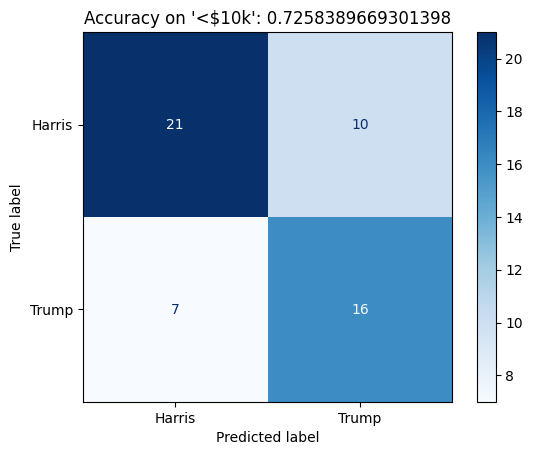

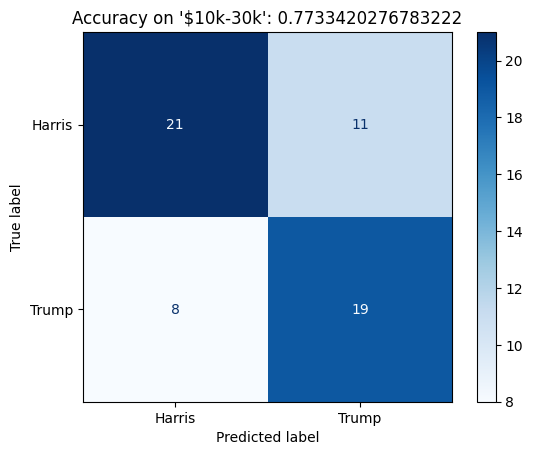

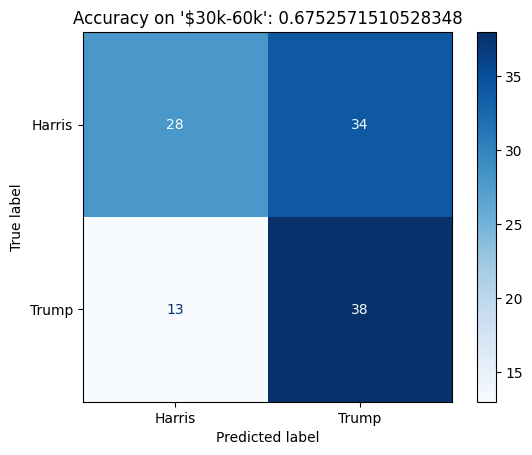

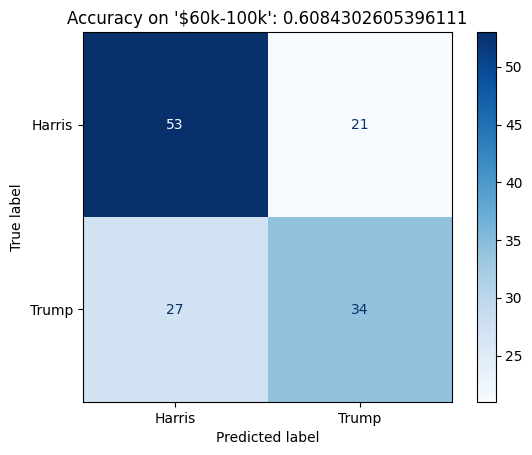

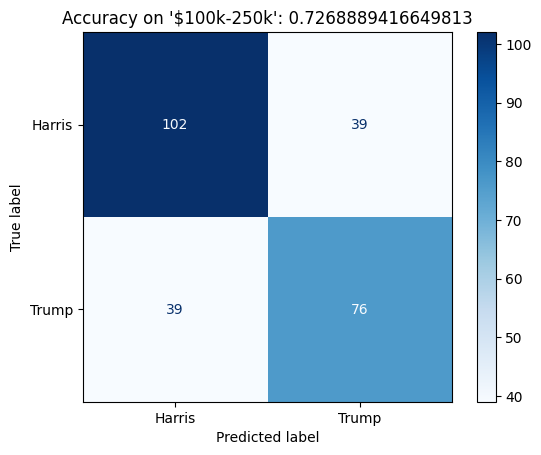

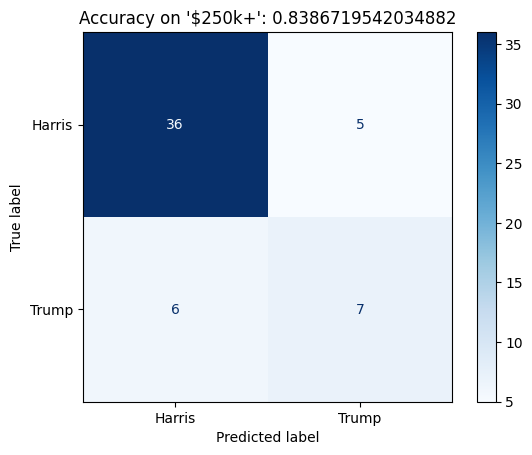

In [17]:
# Income Confusion Matrices
for income, income_df in dfresults.groupby("Household Income"):
    accuracy = accuracy_score(income_df["Actual"], income_df["Prediction"],
                              sample_weight=income_df["Weight"])
    title = f"Accuracy on '{income}': {accuracy}"

    con_mat = confusion_matrix(income_df["Actual"], income_df["Prediction"])
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plt.title(title)

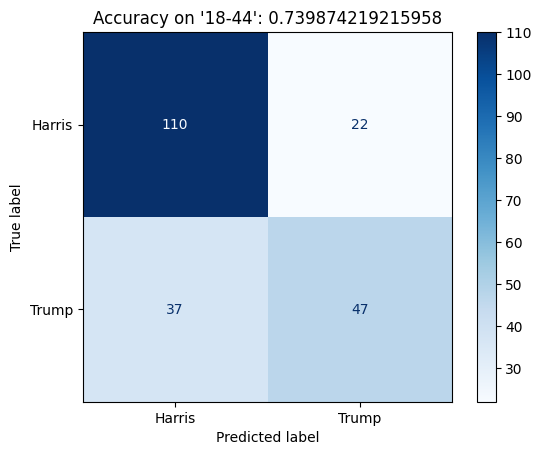

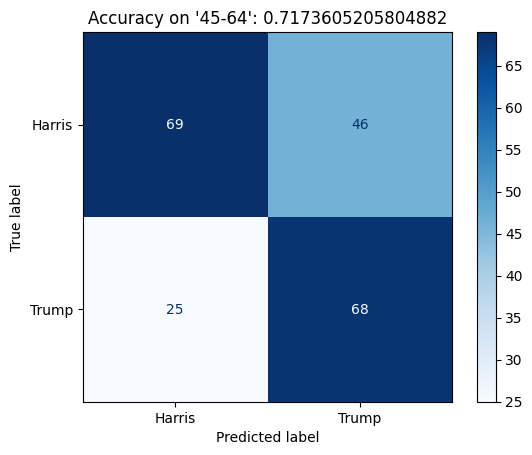

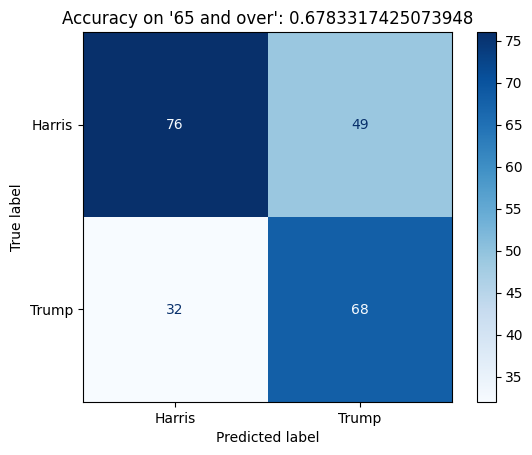

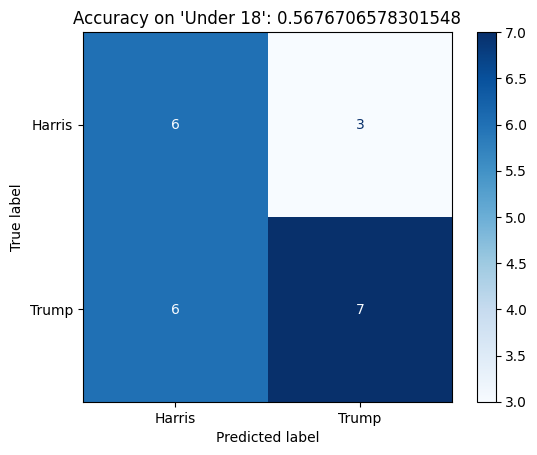

In [18]:
# Age Confusion Matrices
for age, age_df in dfresults.groupby("Age Group"):
    accuracy = accuracy_score(age_df["Actual"], age_df["Prediction"],
                              sample_weight=age_df["Weight"])
    title = f"Accuracy on '{age}': {accuracy}"

    con_mat = confusion_matrix(age_df["Actual"], age_df["Prediction"])
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plt.title(title)

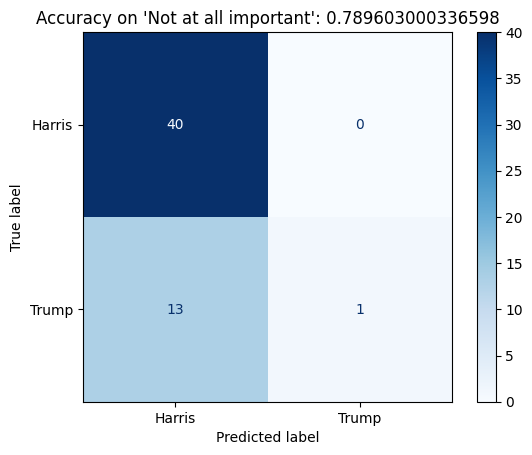

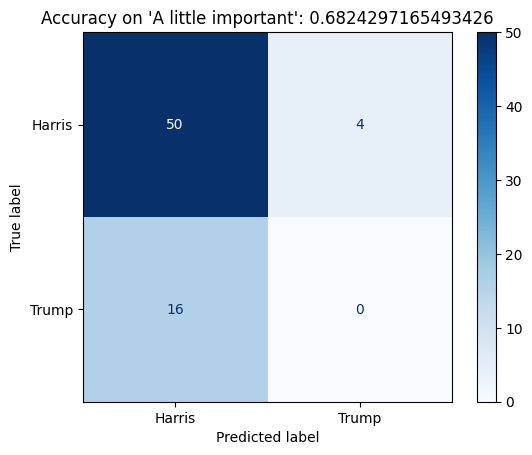

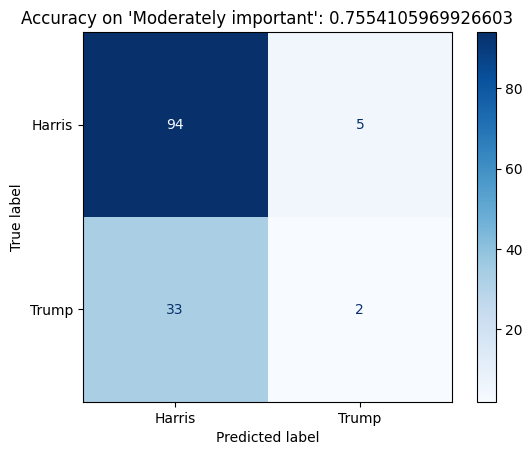

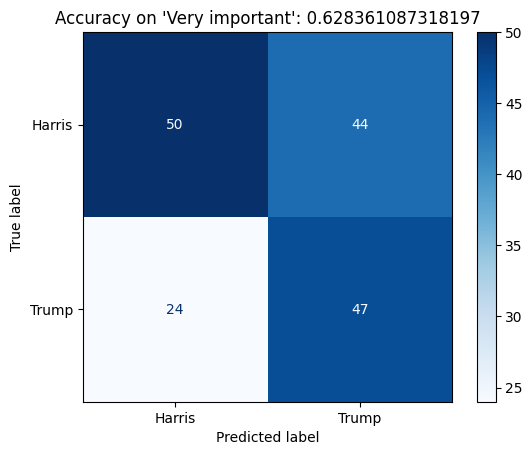

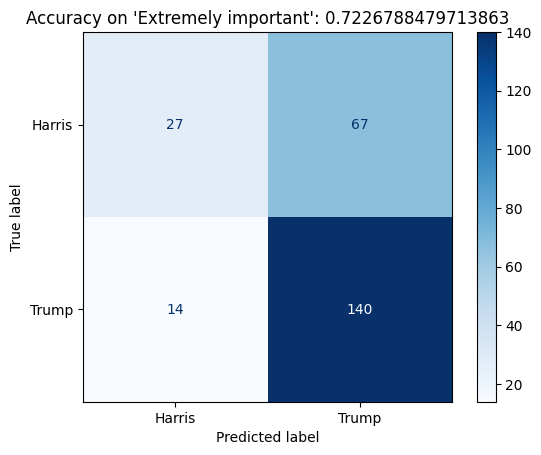

In [19]:
# Nationalism Confusion Matrices
for nation, nation_df in dfresults.groupby("American Identity"):
    accuracy = accuracy_score(nation_df["Actual"], nation_df["Prediction"],
                              sample_weight=nation_df["Weight"])
    title = f"Accuracy on '{nation}': {accuracy}"

    con_mat = confusion_matrix(nation_df["Actual"], nation_df["Prediction"])
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plt.title(title)